#Step 1 — Imports

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, TimeDistributed, Conv2D, MaxPooling2D,
    BatchNormalization, Dropout, Flatten, LSTM, Dense
)
from tensorflow.keras.utils import to_categorical

#Block 2 — Mount drive and load files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Speech_emotion_recognition/RAVDESS"

files = glob.glob(os.path.join(DATA_PATH, "Actor_*", "*.wav"))

print("Total speech files found:", len(files))
print("Sample file:", files[0])

Mounted at /content/drive
Total speech files found: 1440
Sample file: /content/drive/MyDrive/Speech_emotion_recognition/RAVDESS/Actor_24/03-01-01-01-02-02-24.wav


#Step 3: Emotion dictionary

In [9]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

#Step 4 — Build dataframe

In [10]:
data = []

for file in files:
    filename = os.path.basename(file)
    parts = filename.replace(".wav", "").split("-")

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    data.append({
        "path": file,
        "filename": filename,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": emotion_dict[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
    })

df = pd.DataFrame(data)
df.head()
print()
print("\nEmotion counts:")
print(df["emotion"].value_counts())



Emotion counts:
emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


#Step 5 — One emotion distribution graph

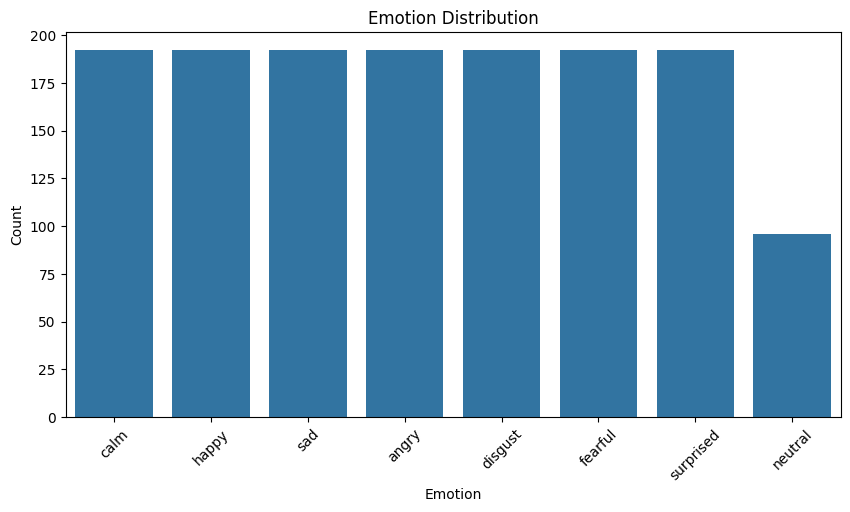

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Step 6 — Mel spectrogram extraction for CNN+LSTM

In [12]:
# For CNN+LSTM, we reshape the mel spectrogram into a sequence of smaller image chunks.

def extract_mel_cnn_lstm(file_path, n_mels=128, max_len=128, n_steps=16):
    signal, sr = librosa.load(file_path, sr=22050)

    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # pad or trim to fixed width
    if mel_db.shape[1] > max_len:
        mel_db = mel_db[:, :max_len]
    else:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant')

    # normalize roughly to 0-1 range
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    # split into time steps
    step_width = max_len // n_steps   # 128//16 = 8
    mel_seq = []

    for i in range(n_steps):
        start = i * step_width
        end = start + step_width
        chunk = mel_db[:, start:end]          # shape (128, 8)
        chunk = np.expand_dims(chunk, axis=-1)  # shape (128, 8, 1)
        mel_seq.append(chunk)

    mel_seq = np.array(mel_seq)   # shape (16, 128, 8, 1)
    return mel_seq

#Step 7 — Build X and y

In [13]:
X = []
y = []

paths = df["path"].values
labels = df["emotion"].values

for i, (file_path, label) in enumerate(zip(paths, labels)):
    if i % 100 == 0:
        print(f"Processing {i}/{len(paths)}")

    feature = extract_mel_cnn_lstm(file_path)
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processing 0/1440
Processing 100/1440
Processing 200/1440
Processing 300/1440
Processing 400/1440
Processing 500/1440
Processing 600/1440
Processing 700/1440
Processing 800/1440
Processing 900/1440
Processing 1000/1440
Processing 1100/1440
Processing 1200/1440
Processing 1300/1440
Processing 1400/1440
X shape: (1440, 16, 128, 8, 1)
y shape: (1440,)


In [14]:
print("One sample shape:", X[0].shape)
print("One label:", y[0])

One sample shape: (16, 128, 8, 1)
One label: neutral


#Step 8 - Visualize one chunk from one sample

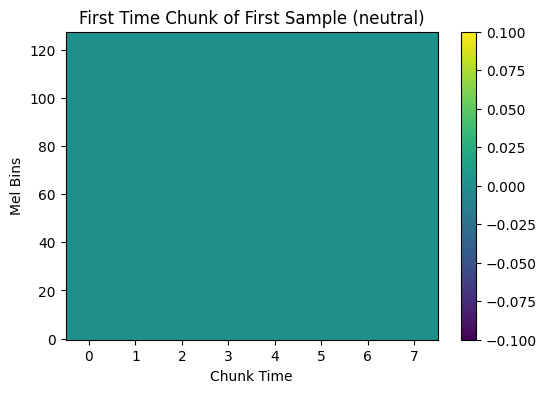

In [15]:
plt.figure(figsize=(6, 4))
plt.imshow(X[0][0, :, :, 0], aspect='auto', origin='lower')
plt.colorbar()
plt.title(f"First Time Chunk of First Sample ({y[0]})")
plt.xlabel("Chunk Time")
plt.ylabel("Mel Bins")
plt.show()

#Steo 9 — Encode labels

In [16]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Class order:", label_encoder.classes_)
print("y_categorical shape:", y_categorical.shape)

Class order: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y_categorical shape: (1440, 8)


#Step 10 — Train-test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1152, 16, 128, 8, 1)
X_test shape: (288, 16, 128, 8, 1)
y_train shape: (1152, 8)
y_test shape: (288, 8)


#Step 11 — Build CNN + LSTM model

In [18]:
model = Sequential([
    Input(shape=(16, 128, 8, 1)),

    TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(BatchNormalization()),

    TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(BatchNormalization()),

    TimeDistributed(Flatten()),

    LSTM(128, return_sequences=False),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

#Step 12 — Compile model

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 128, 8, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 64, 4, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 64, 4, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 64, 4, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 32, 2, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 32, 2, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 4096)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     2,163,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,176 (8.36 MB)

 Trainable params: 2,190,984 (8.36 MB)

 Non-trainable params: 192 (768.00 B)

# Step 13 — Train model

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.2214 - loss: 1.9689 - val_accuracy: 0.1910 - val_loss: 2.0662
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.2674 - loss: 1.8629 - val_accuracy: 0.2569 - val_loss: 1.9452
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.3116 - loss: 1.7616 - val_accuracy: 0.2847 - val_loss: 1.8571
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.3524 - loss: 1.6747 - val_accuracy: 0.3056 - val_loss: 1.8393
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.3924 - loss: 1.6145 - val_accuracy: 0.3056 - val_loss: 1.8770
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.4488 - loss: 1.4694 - val_accuracy: 0.2847 - val_loss: 1.8010
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.5174 - loss: 1.4199 - val_accuracy: 0.3403 - val_loss: 1.8899
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.5495 - loss: 1.2504 - val_accuracy: 0.3889 - v

#Step 15 — Evaluate model

In [21]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 425ms/step - accuracy: 0.5035 - loss: 1.7395
Test Accuracy: 0.5034722089767456
Test Loss: 1.7394945621490479


#STEP  16 — Plot accuracy curves

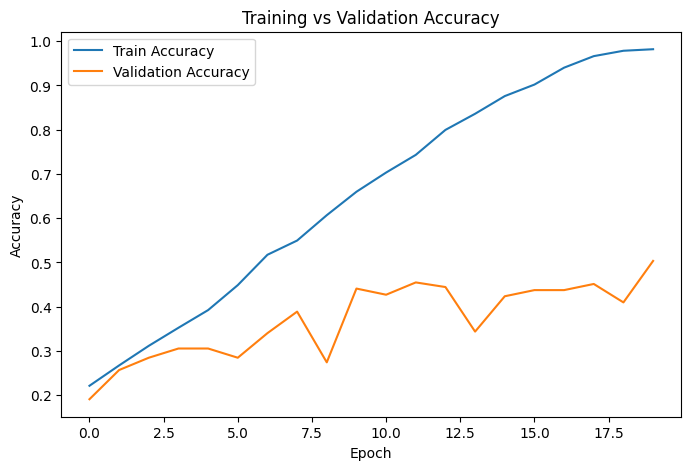

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Step 17 — Plot loss curves

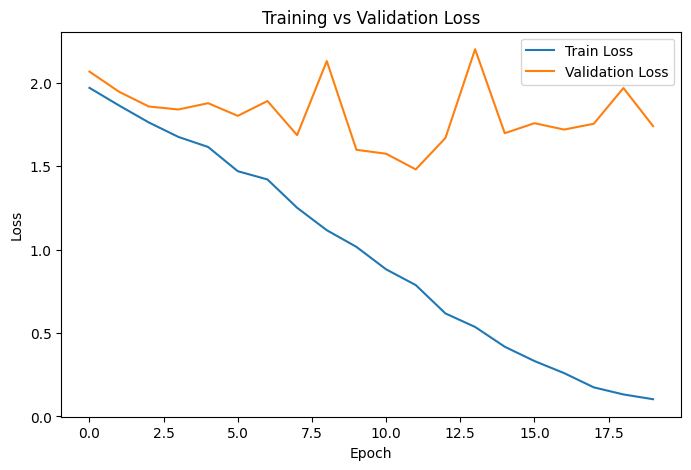

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# step 18 — Confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step


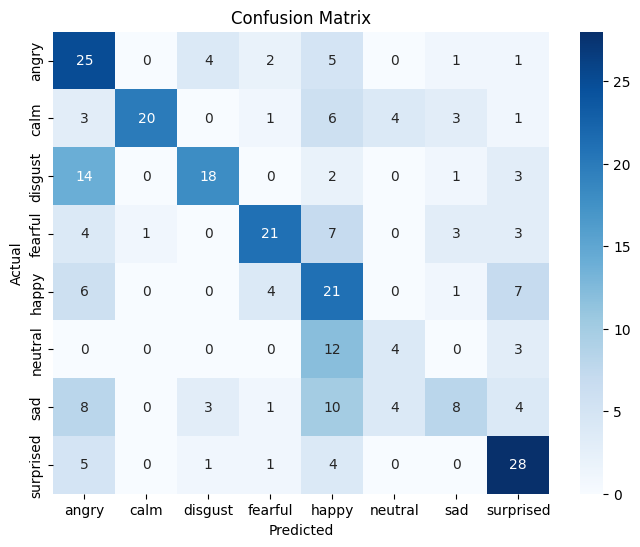

In [24]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#step 19 — Classification report

In [25]:
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.38      0.66      0.49        38
        calm       0.95      0.53      0.68        38
     disgust       0.69      0.47      0.56        38
     fearful       0.70      0.54      0.61        39
       happy       0.31      0.54      0.40        39
     neutral       0.33      0.21      0.26        19
         sad       0.47      0.21      0.29        38
   surprised       0.56      0.72      0.63        39

    accuracy                           0.50       288
   macro avg       0.55      0.48      0.49       288
weighted avg       0.56      0.50      0.50       288



# Step 20 — Exporting the Model

In [26]:
import joblib
import os

SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/models/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save the Keras model in .h5 format
model.save(SAVE_PATH + "cnn_lstm_model.h5") # in train_CNN_LSTM

# Save the label encoder
joblib.dump(label_encoder, SAVE_PATH + "label_encoder.pkl")
print("Saved to:", SAVE_PATH)


Saved to: /content/drive/MyDrive/Speech_emotion_recognition/models/
